In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
## Boston House Pricing Dataset
import pandas as pd
import numpy as np

# Load the Boston housing dataset from the original source repository
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Convert to a DataFrame
columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]
boston_df = pd.DataFrame(data, columns=columns)
boston_df["MEDV"] = target
boston_df.head()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3187/3647880943.py:7: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [ ]:
#independent feature
x = boston_df.iloc[:, :-1]
#dependent feature
y= boston_df.iloc[:, -1]

In [ ]:
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [ ]:
y

,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [ ]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=45)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()

In [ ]:
regressor.fit(x_train,y_train)

DecisionTreeRegressor()

[Text(0.5200177024812734, 0.9761904761904762, 'x[12] <= 9.59\nsquared_error = 80.67\nsamples = 339\nvalue = 22.539'),
 Text(0.27798455056179777, 0.9285714285714286, 'x[5] <= 7.118\nsquared_error = 77.702\nsamples = 136\nvalue = 29.899'),
 Text(0.39900112652153563, 0.9523809523809523, 'True  '),
 Text(0.1657069288389513, 0.8809523809523809, 'x[7] <= 1.545\nsquared_error = 34.773\nsamples = 103\nvalue = 26.394'),
 Text(0.16271067415730336, 0.8333333333333334, 'squared_error = 0.0\nsamples = 3\nvalue = 50.0'),
 Text(0.16870318352059926, 0.8333333333333334, 'x[5] <= 6.542\nsquared_error = 18.597\nsamples = 100\nvalue = 25.686'),
 Text(0.0424625468164794, 0.7857142857142857, 'x[9] <= 222.5\nsquared_error = 7.294\nsamples = 60\nvalue = 23.483'),
 Text(0.006273408239700374, 0.7380952380952381, 'x[10] <= 18.25\nsquared_error = 14.062\nsamples = 2\nvalue = 32.45'),
 Text(0.0032771535580524347, 0.6904761904761905, 'squared_error = 0.0\nsamples = 1\nvalue = 36.2'),
 Text(0.009269662921348315, 0.6

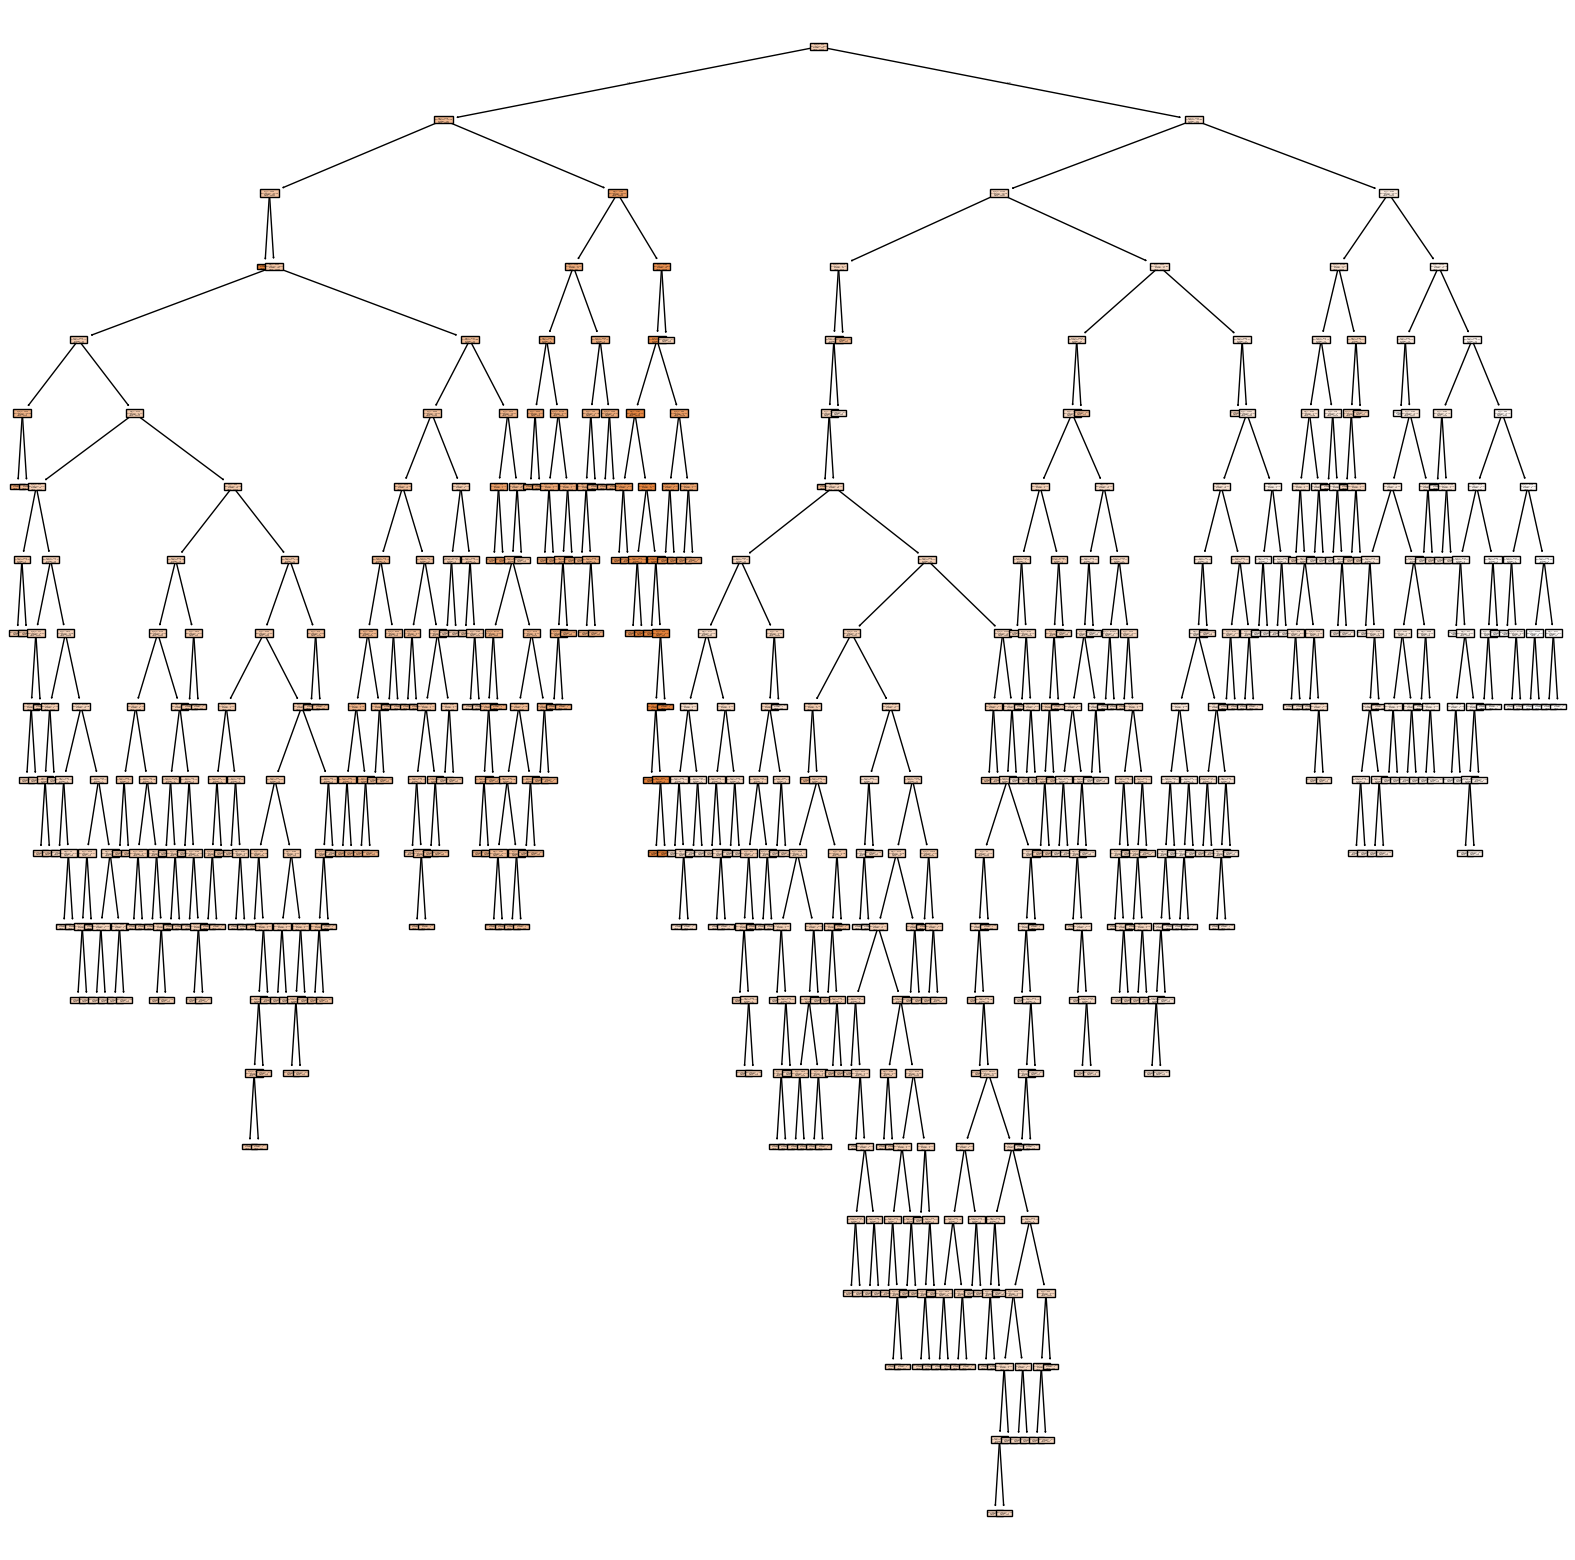

In [ ]:
from sklearn import tree
plt.figure(figsize=(20,20))
tree.plot_tree(regressor,filled=True)

In [ ]:
y_pred=regressor.predict(x_test)

In [ ]:
y_pred

array([20. , 31.6, 23.1, 20.3, 48.3, 12.5, 20.1, 17.5, 33.1, 20.8,  7.5,
       13.1, 43.5, 16.1, 14.6, 20.4, 22.8, 19.1,  7.5, 27. , 20.6, 18.6,
       26.6, 33.4, 21.2, 41.3, 20.3, 10.5, 19.1, 20.1, 21.7, 10.8, 37.3,
       23.1, 43.1, 28.4, 43.1, 16.3, 28. , 37.9, 15.3, 18.1, 12.7, 29.1,
       17.4, 10.2, 28.6, 26.6, 18.1, 18.1, 48.5, 23.1, 22.6, 50. , 16.2,
       27.5,  9.7, 14.4, 19.8, 16.2, 13.4, 12.5, 43.1, 41.3, 14.9, 15.6,
       50. , 48.3, 23.1, 21. , 50. , 21. , 23.1, 14.9, 13.8, 24.2, 29.6,
       11.7, 36.1, 11.3, 14.9, 12.5, 29.1, 29. , 25. , 18.5, 20.6, 14.8,
       14.1,  5.6, 22.6, 13.6, 19.3,  7.5, 30.1, 50. , 22. , 14.1, 28.5,
       22. , 28.1, 35.4, 19.8, 26.6, 19.1, 23. , 28.6, 19.5, 19.4, 15.6,
       25.3, 11.3,  7.2, 23.2, 25. , 29.6, 14. , 12.7, 16.4, 50. , 20.5,
       19.9, 20.1,  7. , 26.6, 22.8, 14.1, 33.4, 37.3, 11.8, 17.1, 19.9,
       16.6, 19.5, 17.4, 13.3, 14.9, 31.1, 22.6, 22.6, 28.7, 24.5, 23.4,
       21. , 15.6, 23. , 23.4, 15.6, 20.8, 17.4, 50

In [ ]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)

In [ ]:
score

0.8226343265489634

In [ ]:
## Hyperparameter Tunning
parameter={
    'criterion':['squared_error','friedman_mse', 'absolute_error' ,'poisson'],
    'splitter':['best', 'random'],
    'max_depth':[1,2,3,4,5,6,7,8,9,10,11,12],
    'max_features': ['auto', 'sqrt', 'log2']

}
regressor=DecisionTreeRegressor()

**`neg_mean_squared_error` ka kaam kya hai?**

Ye GridSearchCV ko batata hai ki alag-alag hyperparameter combinations ko **kis metric se judge** karna hai, aur best model kaun sa hai.

- **MSE (Mean Squared Error)** = `(1/n) * Σ (y_actual − y_predicted)²`. Ye error naapta hai, isliye **jitna kam, utna accha**.
- Lekin scikit-learn ka GridSearchCV hamesha **score ko maximize** karta hai (jitna zyada score, utna accha model).
- Isliye MSE ko **negative** bana diya jata hai: `neg_mean_squared_error = −MSE`.

Is tarah, jiska MSE sabse kam hoga, uska negative score sabse zyada hoga (jaise −5 > −20), aur GridSearchCV usi ko best chunta hai.

**Dhyan dene wali baatein:**

1. Aapko `best_score_` aur `cv_results_` mein **negative values** dikhengi. Ye normal hai.
2. Asli MSE chahiye to minus laga dijiye:

```python
print(-regressorcv.best_score_)   # actual MSE
```

3. RMSE chahiye to:

```python
import numpy as np
print(np.sqrt(-regressorcv.best_score_))
```

4. Regression ke liye aur bhi options hain: `'neg_mean_absolute_error'`, `'r2'`, `'neg_root_mean_squared_error'`. Agar `scoring` na do, to regressors ke liye default `r2` hota hai.

**Sahi code:**

```python
from sklearn.model_selection import GridSearchCV
regressorcv = GridSearchCV(regressor, parameter, cv=5, scoring='neg_mean_squared_error')
regressorcv.fit(X_train, y_train)
print(regressorcv.best_params_)
print(regressorcv.best_score_)
```

---

**scoring=accuracy bhi diya jata hai but ye sab ham use kyu krte hain**

Accha sawal hai. Seedha jawab: **scoring is liye dete hain taaki GridSearchCV ko pata chale ki "accha model" kise maanna hai.** Iske bina wo compare hi nahi kar sakta.

**GridSearchCV kya karta hai?**

Ye har hyperparameter combination try karta hai (jaise `max_depth=3, 5, 10`), har ek ko cross-validation (cv=5) se test karta hai, aur phir ek **number (score)** nikalta hai. Jiska score sabse best, wahi winner. Ye number kaise nikalna hai, wahi `scoring` decide karta hai.

**Accuracy kab, MSE kab?**

Ye problem ke type par depend karta hai:

| Problem                                     | Example                      | Scoring                                                         |
| ------------------------------------------- | ---------------------------- | --------------------------------------------------------------- |
| **Classification** (category predict karna) | spam / not spam, pass / fail | `'accuracy'`, `'f1'`, `'precision'`, `'recall'`, `'roc_auc'`    |
| **Regression** (number predict karna)       | ghar ki price, temperature   | `'neg_mean_squared_error'`, `'neg_mean_absolute_error'`, `'r2'` |

- **Accuracy** = sahi predictions / total predictions. Ye sirf classification mein chalta hai. Regression mein "exact sahi" ka matlab nahi banta (price 50.3 lakh predict kiya aur asli 50.4 tha, to wrong?).
- **MSE** regression mein use hota hai kyunki wo batata hai prediction asli value se **kitni door** hai.

**Alag-alag scoring kyun chuni jaati hai?**

Kyunki sab problems mein "accha" ka matlab alag hota hai. Example:

- Cancer detection mein `accuracy` dhokha de sakti hai. Agar 95% log healthy hain, to ek model jo sabko "healthy" bole, uski accuracy 95% hogi, lekin wo bekaar hai. Wahan `recall` ya `f1` better hai.
- Ghar ki price mein agar bade errors bahut bure hain, to `MSE` use karo (kyunki square se bade errors zyada penalize hote hain). Agar sab errors barabar maanne hain, to `MAE`.

**Short mein:**

`scoring` = wo scale jisse aap model ko judge karte ho. Galat scoring chuni, to GridSearchCV "best" model to dega, lekin wo aapke asli goal ke liye best nahi hoga.

Agar chaho to main ek chhota example dikha sakta hoon jahan same data par alag scoring se alag best model nikalta hai.

In [ ]:
#https://scikit-learn.org/stable/modules/model_evaluation.html (scoring parameter details)
from sklearn.model_selection import GridSearchCV
regressorcv=GridSearchCV(regressor,parameter,cv=5,scoring='neg_mean_squared_error')

In [ ]:
regressorcv.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
480 fits failed out of a total of 1440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
480 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [ ]:
regressorcv.best_params_

{'criterion': 'poisson',
 'max_depth': 3,
 'max_features': 'log2',
 'splitter': 'best'}

In [ ]:
y_yred=regressorcv.predict(x_test)

In [ ]:
r2_score(y_pred,y_test)

0.8403576770053318